# Process [SIMVI](https://www.nature.com/articles/s41467-025-58089-7) Melanoma Data
Available on [Zenodo](https://zenodo.org/records/14708000)

In [3]:
import scanpy as sc
from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from cellina._spatial_utils import weighted_pseudobulks, spatial_neighbors

## Default Params

In [27]:
K_NN = 25
celltype_key = 'celltype_new'
niche_key = "BEST_RESPONSE_BY_SCAN" # NOTE: as in SIMVI
sample_key = "SPID"
batch_key = sample_key  # NOTE: as in SIMVI
n_holdout = 3
n_val_samples = 3
train_frac = False
test_samples = False

backup_url = "https://zenodo.org/records/14708000/files/Melanoma_5612.h5ad?download=1"

## Process Data

In [12]:
base_path = "/data2/a330d/datasets/cosmx/melanoma"

In [5]:
adata = sc.read(
    f"{base_path}/cosmx_melanoma_raw.h5ad",
    backup_url=backup_url,
)
adata.layers["counts"] = adata.X.copy()

spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=K_NN, standardize=True)

# NOTE: merge tumours
adata.obs[celltype_key] = np.where(adata.obs['celltype'].str.contains('Tumor'), 'Tumor', adata.obs['celltype'])

100%|██████████| 456M/456M [02:14<00:00, 3.57MB/s] 


/tmp/ipykernel_1206925/3545368920.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


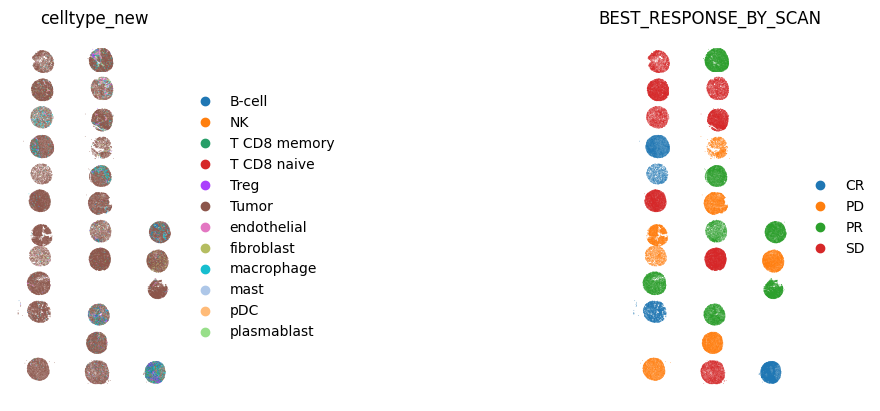

In [6]:
sc.pl.spatial(
    adata,
    color=['celltype_new', niche_key],
    frameon=False,
    spot_size=100
)

In [7]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X / K_NN
# float32
adata.obsm['spatial_x'] = csr_matrix(adata.obsm['spatial_x']).astype(np.float32)

## Save Paramaters and Data

In [29]:
adata.uns['default_params'] = {
    # Data Specific Parameters
    "dataset_name": "cosmx_melanoma",
    "K_NN": K_NN,
    "celltype_key": celltype_key,
    "niche_key": niche_key,
    "sample_key": sample_key,
    "batch_key": batch_key,
    # Split Parameters
    "n_holdout": n_holdout,
    "n_val_samples": n_val_samples,
    "train_frac": train_frac,
    "test_samples": test_samples,
}

In [31]:
adata.write_h5ad(f"{base_path}/melanoma_cosmx.h5ad")